In [18]:

# : Import Libraries 
# =======================

import pandas as pd
import numpy as np
import warnings
import os
from datetime import datetime

# Suppress all warnings (optional - agar bilkul nahi dekhna chahte)
warnings.filterwarnings('ignore')

# Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.options.mode.chained_assignment = None  # Disable chained assignment warning

print("✅ Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"⚠️ Warnings suppressed: {warnings.filters[0] if warnings.filters else 'None'}")

✅ Libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 1.26.4
⚠️ Warnings suppressed: ('ignore', None, <class 'Warning'>, None, 0)


In [19]:

# C: Load Data from Desktop 
# =============================================

import os

# File path (aapka diya hua)
file_path = r"C:\Users\ACER\Desktop\marketing_campaign_dataset.csv"

print(f"🔍 Looking for file at: {file_path}")
print("-" * 50)

# Check if file exists
if os.path.exists(file_path):
    file_size = os.path.getsize(file_path) / 1024  # KB
    print(f"✅ File FOUND!")
    print(f"   📁 Path: {file_path}")
    print(f"   📦 Size: {file_size:.1f} KB")
    
    # Load data
    try:
        df = pd.read_csv(file_path)
        
        print("\n📊 RAW DATA OVERVIEW")
        print("="*50)
        print(f"✅ Successfully loaded!")
        print(f"   Rows: {len(df):,}")
        print(f"   Columns: {len(df.columns)}")
        print(f"   Memory: {df.memory_usage().sum() / 1024**2:.2f} MB")
        
        # Show first few rows
        print("\n📋 First 3 rows:")
        print(df.head(3))
        
    except Exception as e:
        print(f"\n❌ Error loading file: {e}")
        print("\n🔧 Possible solutions:")
        print("   1. Check if file is corrupted")
        print("   2. Check if file is in use by another program")
        print("   3. Try copying file to a different location")
        
else:
    print(f"❌ File NOT found at: {file_path}")
    
    # Show files on Desktop
    print("\n📁 Files found on your Desktop:")
    desktop_path = r"C:\Users\ACER\Desktop"
    
    if os.path.exists(desktop_path):
        all_files = os.listdir(desktop_path)
        csv_files = [f for f in all_files if f.lower().endswith('.csv')]
        
        if csv_files:
            print(f"\n✅ Found {len(csv_files)} CSV files:")
            for i, f in enumerate(csv_files[:10], 1):  # Show first 10
                file_size = os.path.getsize(os.path.join(desktop_path, f)) / 1024
                print(f"   {i}. {f} ({file_size:.1f} KB)")
        else:
            print("   ❌ No CSV files found on Desktop")
            
        # Show any other relevant files
        txt_files = [f for f in all_files if f.lower().endswith('.txt')]
        if txt_files:
            print(f"\n📄 Text files found:")
            for f in txt_files[:5]:
                print(f"   - {f}")
    else:
        print(f"❌ Desktop path not found: {desktop_path}")

🔍 Looking for file at: C:\Users\ACER\Desktop\marketing_campaign_dataset.csv
--------------------------------------------------
✅ File FOUND!
   📁 Path: C:\Users\ACER\Desktop\marketing_campaign_dataset.csv
   📦 Size: 26578.2 KB

📊 RAW DATA OVERVIEW
✅ Successfully loaded!
   Rows: 200,000
   Columns: 16
   Memory: 24.41 MB

📋 First 3 rows:
   Campaign_ID              Company Campaign_Type Target_Audience Duration  \
0            1  Innovate Industries         Email       Men 18-24  30 days   
1            2       NexGen Systems         Email     Women 35-44  60 days   
2            3    Alpha Innovations    Influencer       Men 25-34  30 days   

  Channel_Used  Conversion_Rate Acquisition_Cost  ROI     Location Language  \
0   Google Ads             0.04       $16,174.00 6.29      Chicago  Spanish   
1   Google Ads             0.12       $11,566.00 5.61     New York   German   
2      YouTube             0.07       $10,200.00 7.18  Los Angeles   French   

   Clicks  Impressions  Engage

In [20]:

# : Quick Data Preview
# =============================================

print("\n📋 FIRST 5 ROWS:")
print(df.head())

print("\n📋 COLUMN NAMES:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")

print("\n📋 DATA TYPES:")
print(df.dtypes)

print("\n📋 BASIC INFO:")
df.info()


📋 FIRST 5 ROWS:
   Campaign_ID              Company Campaign_Type Target_Audience Duration  \
0            1  Innovate Industries         Email       Men 18-24  30 days   
1            2       NexGen Systems         Email     Women 35-44  60 days   
2            3    Alpha Innovations    Influencer       Men 25-34  30 days   
3            4   DataTech Solutions       Display        All Ages  60 days   
4            5       NexGen Systems         Email       Men 25-34  15 days   

  Channel_Used  Conversion_Rate Acquisition_Cost  ROI     Location  Language  \
0   Google Ads             0.04       $16,174.00 6.29      Chicago   Spanish   
1   Google Ads             0.12       $11,566.00 5.61     New York    German   
2      YouTube             0.07       $10,200.00 7.18  Los Angeles    French   
3      YouTube             0.11       $12,724.00 5.55        Miami  Mandarin   
4      YouTube             0.05       $16,452.00 6.50  Los Angeles  Mandarin   

   Clicks  Impressions  Engagemen

In [21]:

# : Data Quality Report
# =============================================

print("🔍 DATA QUALITY REPORT")
print("="*50)

# 1. Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing': missing,
    'Percentage': missing_pct
}).round(2)

print("\n1️⃣ MISSING VALUES:")
print(missing_df[missing_df['Missing'] > 0] if any(missing > 0) else "   ✅ No missing values!")

# 2. Duplicates
duplicates = df.duplicated().sum()
print(f"\n2️⃣ DUPLICATE ROWS: {duplicates}")

# 3. Basic Stats for numeric columns
print("\n3️⃣ BASIC STATISTICS:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(df[numeric_cols].describe())

# 4. Unique values in categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("\n4️⃣ UNIQUE VALUES IN CATEGORIES:")
for col in categorical_cols[:5]:  # First 5 categorical columns
    print(f"   {col:25}: {df[col].nunique():3} unique values")
    if col == 'Acquisition_Cost':  # Show sample of cost column
        print(f"      Sample: {df[col].head(3).tolist()}")

🔍 DATA QUALITY REPORT

1️⃣ MISSING VALUES:
   ✅ No missing values!

2️⃣ DUPLICATE ROWS: 0

3️⃣ BASIC STATISTICS:
       Campaign_ID  Conversion_Rate       ROI    Clicks  Impressions  \
count    200000.00        200000.00 200000.00 200000.00    200000.00   
mean     100000.50             0.08      5.00    549.77      5507.30   
std       57735.17             0.04      1.73    260.02      2596.86   
min           1.00             0.01      2.00    100.00      1000.00   
25%       50000.75             0.05      3.50    325.00      3266.00   
50%      100000.50             0.08      5.01    550.00      5517.50   
75%      150000.25             0.12      6.51    775.00      7753.00   
max      200000.00             0.15      8.00   1000.00     10000.00   

       Engagement_Score  
count         200000.00  
mean               5.49  
std                2.87  
min                1.00  
25%                3.00  
50%                5.00  
75%                8.00  
max               10.00  

4️⃣

In [22]:
#Clean Cost Column
# =============================================

print("💰 CLEANING ACQUISITION_COST")
print("="*50)

# Before cleaning
print("\n📋 BEFORE CLEANING (Sample):")
print(df['Acquisition_Cost'].head(10).tolist())

# Create a copy for cleaned data
df_clean = df.copy()

# Clean the cost column
df_clean['Acquisition_Cost'] = df_clean['Acquisition_Cost'].astype(str)
df_clean['Acquisition_Cost'] = df_clean['Acquisition_Cost'].str.replace('$', '')
df_clean['Acquisition_Cost'] = df_clean['Acquisition_Cost'].str.replace(',', '')
df_clean['Acquisition_Cost'] = pd.to_numeric(df_clean['Acquisition_Cost'], errors='coerce')

print("\n📋 AFTER CLEANING (Sample):")
print(df_clean['Acquisition_Cost'].head(10).tolist())

# Check for any conversion errors
errors = df_clean['Acquisition_Cost'].isna().sum()
if errors > 0:
    print(f"\n⚠️ {errors} rows could not be converted. These will be filled with median.")
    median_cost = df_clean['Acquisition_Cost'].median()
    df_clean['Acquisition_Cost'].fillna(median_cost, inplace=True)

# Summary
print(f"\n✅ Min Cost: ${df_clean['Acquisition_Cost'].min():,.2f}")
print(f"✅ Max Cost: ${df_clean['Acquisition_Cost'].max():,.2f}")
print(f"✅ Avg Cost: ${df_clean['Acquisition_Cost'].mean():,.2f}")
print(f"✅ Total Spend: ${df_clean['Acquisition_Cost'].sum():,.2f}")

💰 CLEANING ACQUISITION_COST

📋 BEFORE CLEANING (Sample):
['$16,174.00', '$11,566.00', '$10,200.00', '$12,724.00', '$16,452.00', '$9,716.00', '$11,067.00', '$13,280.00', '$18,066.00', '$13,766.00']

📋 AFTER CLEANING (Sample):
[16174.0, 11566.0, 10200.0, 12724.0, 16452.0, 9716.0, 11067.0, 13280.0, 18066.0, 13766.0]

✅ Min Cost: $5,000.00
✅ Max Cost: $20,000.00
✅ Avg Cost: $12,504.39
✅ Total Spend: $2,500,878,608.00


In [23]:

# : Date Processing
# ===================

print("📅 PROCESSING DATES")
print("="*50)

# Convert to datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

print(f"Date Range: {df_clean['Date'].min()} to {df_clean['Date'].max()}")
print(f"Total Days: {(df_clean['Date'].max() - df_clean['Date'].min()).days} days")

# Extract date features
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Month_Name'] = df_clean['Date'].dt.month_name()
df_clean['Quarter'] = 'Q' + df_clean['Date'].dt.quarter.astype(str)
df_clean['Day_of_Week'] = df_clean['Date'].dt.day_name()
df_clean['Week_Number'] = df_clean['Date'].dt.isocalendar().week
df_clean['Is_Weekend'] = df_clean['Date'].dt.dayofweek.isin([5,6]).astype(int)

# Business season
df_clean['Season'] = 'Other'
df_clean.loc[df_clean['Month'].isin([12,1,2]), 'Season'] = 'Winter'
df_clean.loc[df_clean['Month'].isin([3,4,5]), 'Season'] = 'Spring'
df_clean.loc[df_clean['Month'].isin([6,7,8]), 'Season'] = 'Summer'
df_clean.loc[df_clean['Month'].isin([9,10,11]), 'Season'] = 'Fall'

print("\n✅ Added date features:")
date_features = ['Year', 'Month', 'Quarter', 'Season', 'Is_Weekend']
for feat in date_features:
    print(f"   - {feat}: {df_clean[feat].nunique()} unique values")

📅 PROCESSING DATES
Date Range: 2021-01-01 00:00:00 to 2021-12-31 00:00:00
Total Days: 364 days

✅ Added date features:
   - Year: 1 unique values
   - Month: 12 unique values
   - Quarter: 4 unique values
   - Season: 4 unique values
   - Is_Weekend: 2 unique values


In [24]:

# : Business Metrics
# ==========================

print("📊 CREATING BUSINESS METRICS")
print("="*50)

# 1. Click Through Rate (CTR)
df_clean['CTR'] = (df_clean['Clicks'] / df_clean['Impressions']) * 100
df_clean['CTR'] = df_clean['CTR'].round(2)

# 2. Cost Per Click (CPC)
df_clean['CPC'] = df_clean['Acquisition_Cost'] / df_clean['Clicks']
df_clean['CPC'] = df_clean['CPC'].replace([np.inf, -np.inf], np.nan)
df_clean['CPC'].fillna(df_clean['Acquisition_Cost'].mean() / df_clean['Clicks'].mean(), inplace=True)
df_clean['CPC'] = df_clean['CPC'].round(2)

# 3. Profit (Estimated Revenue - Cost)
# ROI = (Revenue - Cost) / Cost, so Revenue = Cost * (1 + ROI)
df_clean['Estimated_Revenue'] = df_clean['Acquisition_Cost'] * (1 + df_clean['ROI'])
df_clean['Profit'] = df_clean['Estimated_Revenue'] - df_clean['Acquisition_Cost']

# 4. Return on Ad Spend (ROAS)
df_clean['ROAS'] = df_clean['Estimated_Revenue'] / df_clean['Acquisition_Cost']
df_clean['ROAS'] = df_clean['ROAS'].round(2)

# 5. Cost Per Conversion (approximate)
df_clean['Cost_Per_Conversion'] = df_clean['Acquisition_Cost'] / (df_clean['Conversion_Rate'] * 100)
df_clean['Cost_Per_Conversion'] = df_clean['Cost_Per_Conversion'].replace([np.inf, -np.inf], np.nan)
df_clean['Cost_Per_Conversion'].fillna(df_clean['Acquisition_Cost'].mean() / 0.1, inplace=True)
df_clean['Cost_Per_Conversion'] = df_clean['Cost_Per_Conversion'].round(2)

print("\n✅ New Business Metrics:")
metrics = ['CTR', 'CPC', 'Profit', 'ROAS', 'Cost_Per_Conversion']
for metric in metrics:
    print(f"   - {metric:20}: {df_clean[metric].mean():.2f} (avg)")

print("\n📋 Sample with new metrics:")
print(df_clean[['Campaign_ID', 'Acquisition_Cost', 'ROI', 'Profit', 'CPC', 'CTR']].head())

📊 CREATING BUSINESS METRICS

✅ New Business Metrics:
   - CTR                 : 14.04 (avg)
   - CPC                 : 32.01 (avg)
   - Profit              : 62586.94 (avg)
   - ROAS                : 6.00 (avg)
   - Cost_Per_Conversion : 2481.99 (avg)

📋 Sample with new metrics:
   Campaign_ID  Acquisition_Cost  ROI    Profit   CPC   CTR
0            1          16174.00 6.29 101734.46 31.96 26.33
1            2          11566.00 5.61  64885.26 99.71  1.54
2            3          10200.00 7.18  73236.00 17.47  7.59
3            4          12724.00 5.55  70618.20 58.64 11.92
4            5          16452.00 6.50 106938.00 43.41  9.02


In [25]:

# : Category Standardization
# ==========================

print("🏷️ STANDARDIZING CATEGORIES")
print("="*50)

# 1. Channel grouping
channel_mapping = {
    'Google Ads': 'Search',
    'YouTube': 'Video',
    'Facebook': 'Social',
    'Instagram': 'Social',
    'Email': 'Email',
    'Website': 'Display'
}
df_clean['Channel_Group'] = df_clean['Channel_Used'].map(channel_mapping).fillna('Other')

# 2. Campaign Type grouping
campaign_mapping = {
    'Email': 'Retention',
    'Social Media': 'Engagement',
    'Influencer': 'Brand Awareness',
    'Display': 'Brand Awareness',
    'Search': 'Performance'
}
df_clean['Campaign_Objective'] = df_clean['Campaign_Type'].map(campaign_mapping).fillna('Other')

# 3. Audience segmentation
df_clean['Gender_Target'] = 'All'
df_clean.loc[df_clean['Target_Audience'].str.contains('Men'), 'Gender_Target'] = 'Male'
df_clean.loc[df_clean['Target_Audience'].str.contains('Women'), 'Gender_Target'] = 'Female'

df_clean['Age_Target'] = df_clean['Target_Audience'].str.extract('(\d+-\d+)').fillna('All Ages')

print("\n✅ Standardized Categories:")
print(f"   Channel Groups: {df_clean['Channel_Group'].nunique()} → {df_clean['Channel_Group'].unique().tolist()}")
print(f"   Campaign Objectives: {df_clean['Campaign_Objective'].nunique()} → {df_clean['Campaign_Objective'].unique().tolist()}")
print(f"   Gender Target: {df_clean['Gender_Target'].nunique()} → {df_clean['Gender_Target'].unique().tolist()}")

🏷️ STANDARDIZING CATEGORIES

✅ Standardized Categories:
   Channel Groups: 5 → ['Search', 'Video', 'Social', 'Display', 'Email']
   Campaign Objectives: 4 → ['Retention', 'Brand Awareness', 'Performance', 'Engagement']
   Gender Target: 3 → ['Male', 'Female', 'All']


In [26]:
# =============================================
# CELL 9: ROI Segmentation
# =============================================

print("📈 ROI SEGMENTATION")
print("="*50)

# ROI Categories for business users
df_clean['ROI_Performance'] = 'Average'
df_clean.loc[df_clean['ROI'] < 3, 'ROI_Performance'] = 'Poor (ROI < 3x)'
df_clean.loc[df_clean['ROI'] > 7, 'ROI_Performance'] = 'Excellent (ROI > 7x)'
df_clean.loc[(df_clean['ROI'] >= 5) & (df_clean['ROI'] <= 7), 'ROI_Performance'] = 'Good (ROI 5-7x)'

# Investment Priority (for budget allocation)
df_clean['Investment_Priority'] = 'Low'
df_clean.loc[df_clean['ROI'] > df_clean['ROI'].median(), 'Investment_Priority'] = 'Medium'
df_clean.loc[df_clean['ROI'] > df_clean['ROI'].quantile(0.75), 'Investment_Priority'] = 'High'
df_clean.loc[df_clean['ROI'] > df_clean['ROI'].quantile(0.9), 'Investment_Priority'] = 'Critical'

print("\n✅ ROI Performance Distribution:")
print(df_clean['ROI_Performance'].value_counts())

print("\n✅ Investment Priority Distribution:")
print(df_clean['Investment_Priority'].value_counts())

📈 ROI SEGMENTATION

✅ ROI Performance Distribution:
ROI_Performance
Good (ROI 5-7x)         67099
Average                 66333
Excellent (ROI > 7x)    33301
Poor (ROI < 3x)         33267
Name: count, dtype: int64

✅ Investment Priority Distribution:
Investment_Priority
Low         100292
Medium       50014
High         29762
Critical     19932
Name: count, dtype: int64


In [27]:

#  Outlier Detection
# =============================================

print("🚨 OUTLIER DETECTION")
print("="*50)

# Function to flag outliers
def flag_outliers(df, column, threshold=3):
    mean = df[column].mean()
    std = df[column].std()
    df[f'{column}_Outlier'] = ((df[column] - mean).abs() > threshold * std).astype(int)

# Flag outliers in key metrics
flag_outliers(df_clean, 'Acquisition_Cost')
flag_outliers(df_clean, 'ROI')
flag_outliers(df_clean, 'CTR')
flag_outliers(df_clean, 'Clicks')

print("\n📊 OUTLIER SUMMARY:")
outlier_cols = ['Acquisition_Cost_Outlier', 'ROI_Outlier', 'CTR_Outlier', 'Clicks_Outlier']
for col in outlier_cols:
    count = df_clean[col].sum()
    pct = (count / len(df_clean)) * 100
    print(f"   {col:25}: {count:4} outliers ({pct:.1f}%)")

# Overall outlier flag (any metric)
df_clean['Has_Outlier'] = (df_clean[outlier_cols].sum(axis=1) > 0).astype(int)
print(f"\n✅ Total campaigns with outliers: {df_clean['Has_Outlier'].sum()} ({df_clean['Has_Outlier'].mean()*100:.1f}%)")

🚨 OUTLIER DETECTION

📊 OUTLIER SUMMARY:
   Acquisition_Cost_Outlier :    0 outliers (0.0%)
   ROI_Outlier              :    0 outliers (0.0%)
   CTR_Outlier              : 5049 outliers (2.5%)
   Clicks_Outlier           :    0 outliers (0.0%)

✅ Total campaigns with outliers: 5049 (2.5%)


In [28]:

# : Final Data Check
# =============================================

print("🔍 FINAL DATA CHECK")
print("="*50)

print(f"\n📊 Final Dataset Shape: {df_clean.shape}")
print(f"   Original columns: 16")
print(f"   New columns added: {len(df_clean.columns) - 16}")
print(f"   Total columns: {len(df_clean.columns)}")

print("\n📋 ALL COLUMNS (Final):")
for i, col in enumerate(df_clean.columns, 1):
    print(f"{i:3}. {col}")

print("\n💰 BUSINESS SUMMARY:")
print(f"   Total Campaigns: {len(df_clean):,}")
print(f"   Total Spend: ${df_clean['Acquisition_Cost'].sum():,.0f}")
print(f"   Total Estimated Revenue: ${df_clean['Estimated_Revenue'].sum():,.0f}")
print(f"   Total Profit: ${df_clean['Profit'].sum():,.0f}")
print(f"   Average ROI: {df_clean['ROI'].mean():.2f}x")
print(f"   Average CTR: {df_clean['CTR'].mean():.2f}%")
print(f"   Average CPC: ${df_clean['CPC'].mean():.2f}")

# Channel performance
print("\n📊 CHANNEL PERFORMANCE (by ROI):")
channel_perf = df_clean.groupby('Channel_Used').agg({
    'ROI': 'mean',
    'Profit': 'sum',
    'Acquisition_Cost': 'sum',
    'Campaign_ID': 'count'
}).round(2).sort_values('ROI', ascending=False)

channel_perf['ROI_vs_Avg'] = (channel_perf['ROI'] / df_clean['ROI'].mean() - 1) * 100
print(channel_perf)

# =============================================
# CELL 12: Save Cleaned Data
# =============================================

# Save to Desktop
output_path = r"C:\Users\ACER\Desktop\marketing_roi_cleaned.csv"
df_clean.to_csv(output_path, index=False)
print(f"\n✅ Full cleaned data saved to: {output_path}")

# Save sample for quick view
sample_path = r"C:\Users\ACER\Desktop\marketing_roi_sample.csv"
df_clean.head(1000).to_csv(sample_path, index=False)
print(f"✅ Sample data saved to: {sample_path}")

print("\n🎉 DATA CLEANING COMPLETE!")
print("="*50)
print(f"📁 Files created on your Desktop:")
print(f"   1. marketing_roi_cleaned.csv (all {len(df_clean):,} rows)")
print(f"   2. marketing_roi_sample.csv (first 1,000 rows)")
print("\n🚀 Next: Load into Power BI!")

🔍 FINAL DATA CHECK

📊 Final Dataset Shape: (200000, 41)
   Original columns: 16
   New columns added: 25
   Total columns: 41

📋 ALL COLUMNS (Final):
  1. Campaign_ID
  2. Company
  3. Campaign_Type
  4. Target_Audience
  5. Duration
  6. Channel_Used
  7. Conversion_Rate
  8. Acquisition_Cost
  9. ROI
 10. Location
 11. Language
 12. Clicks
 13. Impressions
 14. Engagement_Score
 15. Customer_Segment
 16. Date
 17. Year
 18. Month
 19. Month_Name
 20. Quarter
 21. Day_of_Week
 22. Week_Number
 23. Is_Weekend
 24. Season
 25. CTR
 26. CPC
 27. Estimated_Revenue
 28. Profit
 29. ROAS
 30. Cost_Per_Conversion
 31. Channel_Group
 32. Campaign_Objective
 33. Gender_Target
 34. Age_Target
 35. ROI_Performance
 36. Investment_Priority
 37. Acquisition_Cost_Outlier
 38. ROI_Outlier
 39. CTR_Outlier
 40. Clicks_Outlier
 41. Has_Outlier

💰 BUSINESS SUMMARY:
   Total Campaigns: 200,000
   Total Spend: $2,500,878,608
   Total Estimated Revenue: $15,018,267,282
   Total Profit: $12,517,388,674
   

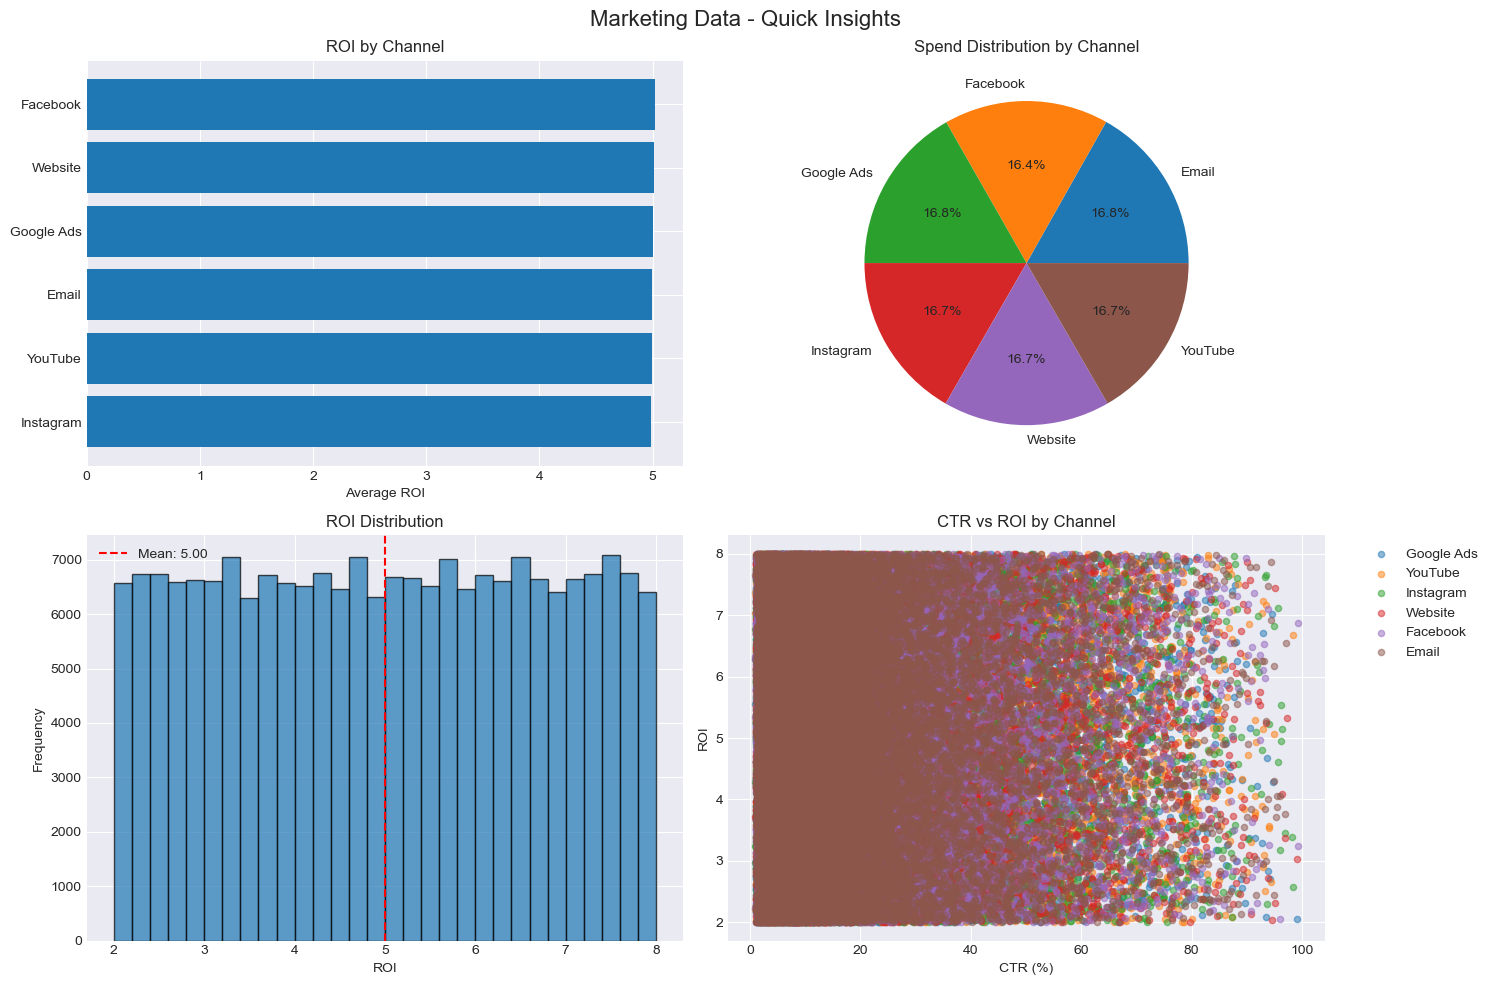

✅ Quick insights chart saved to Desktop


In [30]:

#  Visualizations
# ================

import matplotlib.pyplot as plt

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Marketing Data - Quick Insights', fontsize=16)

# 1. ROI by Channel
ax1 = axes[0, 0]
channel_roi = df_clean.groupby('Channel_Used')['ROI'].mean().sort_values()
ax1.barh(channel_roi.index, channel_roi.values)
ax1.set_xlabel('Average ROI')
ax1.set_title('ROI by Channel')

# 2. Spend Distribution
ax2 = axes[0, 1]
spend_by_channel = df_clean.groupby('Channel_Used')['Acquisition_Cost'].sum()
ax2.pie(spend_by_channel.values, labels=spend_by_channel.index, autopct='%1.1f%%')
ax2.set_title('Spend Distribution by Channel')

# 3. ROI Distribution
ax3 = axes[1, 0]
ax3.hist(df_clean['ROI'], bins=30, edgecolor='black', alpha=0.7)
ax3.axvline(df_clean['ROI'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["ROI"].mean():.2f}')
ax3.set_xlabel('ROI')
ax3.set_ylabel('Frequency')
ax3.set_title('ROI Distribution')
ax3.legend()

# 4. CTR vs ROI Scatter
ax4 = axes[1, 1]
colors = {'YouTube': 'red', 'Facebook': 'blue', 'Instagram': 'purple', 'Google Ads': 'green', 'Email': 'orange'}
for channel in df_clean['Channel_Used'].unique():
    channel_data = df_clean[df_clean['Channel_Used'] == channel]
    ax4.scatter(channel_data['CTR'], channel_data['ROI'], alpha=0.5, label=channel, s=20)
ax4.set_xlabel('CTR (%)')
ax4.set_ylabel('ROI')
ax4.set_title('CTR vs ROI by Channel')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(r"C:\Users\ACER\Desktop\marketing_quick_insights.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Quick insights chart saved to Desktop")